In [4]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler,StandardScaler,RobustScaler,LabelEncoder,OneHotEncoder,OrdinalEncoder
from category_encoders import TargetEncoder

In [5]:
df=pd.read_csv('Salary Data.csv')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [7]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [8]:
df.dropna(inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 373 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 20.4+ KB


In [11]:
x=df.drop(columns='Salary')
y=df['Salary']

In [12]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [13]:
obj_cols=x.select_dtypes(include='object').columns

In [15]:
df.corr(numeric_only=True)

,Age,Years of Experience,Salary
Age,1.000000,0.979128,0.922335
Years of Experience,0.979128,1.000000,0.930338
Salary,0.922335,0.930338,1.000000


In [16]:
x[obj_cols].nunique()

Gender               2
Education Level      3
Job Title          174
dtype: int64

In [17]:
x_train['Education Level'].unique()

array(["Bachelor's", "Master's", 'PhD'], dtype=object)

<Axes: >

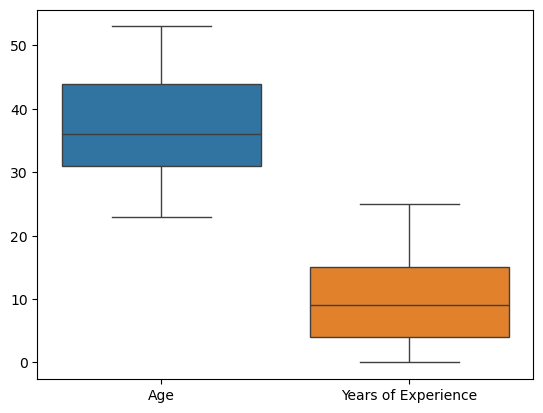

In [18]:
sns.boxplot(x)

In [19]:
x['Education Level'].value_counts()

Education Level
Bachelor's    224
Master's       98
PhD            51
Name: count, dtype: int64

# USING PIPELINE

In [20]:
transformer=ColumnTransformer(
    transformers=[(
        'scaler',StandardScaler(),['Age','Years of Experience']),
        ('One_Hot_Encoder',OneHotEncoder(),['Gender']),
        ('Ordinal_encoder',OrdinalEncoder(categories=[["Bachelor's","Master's","PhD"]]),['Education Level']),
        ('Target_encoder',TargetEncoder(handle_unknown='value',cols=['Job Title']),['Job Title'])
        ],remainder='passthrough'
    )

In [21]:
main_pipeline=Pipeline(steps=[('transforming',transformer),('model',DecisionTreeRegressor())])

In [22]:
model=main_pipeline.fit(x_train,y_train)

In [23]:
y_pred=model.predict(x_train)

In [24]:
ytest_pred=model.predict(x_test)

In [25]:
model.score(x_train,y_train)

0.9991243069602964

In [26]:
model.score(x_test,y_test)

0.5954257622493772

# Here the model is overfit and decision tree usually is overfit hence we use random forest, so check this example in random forest section, but the dataset is too small try for different one